### Converting video 004 h5 file to csv  

In [50]:
%matplotlib widget
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import random

#NOTE! intruder refers to the black mouse, but the naming for intruder refers to the white mouse in CalMS21 dataset (& vice versa)

In [2]:
###video files for determining biologically implausible motion
'''
#video 8
df8 = pd.read_hdf('mouse008_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.h5')
conv_csv_vid8 = df8.to_csv('mouse008_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.csv',index=False)

#video 36
df36 = pd.read_hdf('mouse036_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.h5')
conv_csv_vid36 = df36.to_csv('mouse036_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.csv',index=False)

dataset_path8 = 'mouse008_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.csv'
dataset_path36 = 'mouse036_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.csv'

csv_df8 = pd.read_csv(dataset_path8)
csv_df36 = pd.read_csv(dataset_path36)

#display(csv_df8)
#display(csv_df36)


#find biologically implausible motion by determing a threshold
intruder8_neck = csv_df8.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.33':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.34']
intruder8_neck_spec = intruder8_neck.loc[6000:6500]
display(intruder8_neck_spec)

intruder8_neck_spec_ind = intruder8_neck_spec.index.to_list()
intruder8_neck_spec_x = np.array(intruder8_neck_spec.loc[:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.33'].to_numpy(),dtype=float)
intruder8_neck_spec_y = np.array(intruder8_neck_spec.loc[:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.34'].to_numpy(),dtype=float)

plt.close()

#plot time vs x & time vs y
plt.figure(3)
plt.plot(intruder8_neck_spec_ind,intruder8_neck_spec_x)
plt.plot(intruder8_neck_spec_ind,intruder8_neck_spec_y)
plt.show()

#plot time vs delta column
plt.figure(4)
np_intruder8_neck = np.array(intruder8_neck_spec.to_numpy(),dtype=float)
np_intruder8_neck_prev = np_intruder8_neck[:-1]
np_intruder8_neck_aft = np_intruder8_neck[1:]
delta_col_neck = np.abs(np_intruder8_neck_aft - np_intruder8_neck_prev)
plt.plot(intruder8_neck_spec_ind[:-1],delta_col_neck[:,0])
plt.plot(intruder8_neck_spec_ind[:-1],delta_col_neck[:,1])
plt.show()

'''
print(None)
'''

#original likelihood distribution
intruder_nose_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.2']
np_intruder_nose_lik = np.array(intruder_nose_lik.to_numpy(),dtype=float)
plt.figure(1)
plt.hist(np_intruder_nose_lik,bins=20)
plt.show()

#new likelihood distribution
#filtered data with 5% of data with lowest likelihood removed
intruder_nose_lik = intruder_nose_lik.astype(float)
threshold = intruder_nose_lik.quantile(0.05)
filtered_threshold_perc = intruder_nose_lik[intruder_nose_lik > threshold]

np_filtered_threshold_perc = np.array(filtered_threshold_perc.to_numpy(),dtype=float)
plt.figure(2)
plt.hist(np_filtered_threshold_perc,bins=20)
plt.show()

#filtered dataframe
ind_filtered_threshold_perc = filtered_threshold_perc.index.tolist()
filt_intruder_nose = intruder_nose.loc[ind_filtered_threshold_perc]
#display(filt_intruder_nose)
'''
print(None)
'''
#extract displacements of nose
delt_intruder_nose = np_intruder_nose[1:,:] - np_intruder_nose[:-1,:] #delta columns
#print(delt_intruder_nose)

disp_nose = np.sqrt(delt_intruder_nose[:,0]**2 + delt_intruder_nose[:,1]**2) #displacement
#print(disp_nose)

flagged_fr = [] #flagged frames of possible errors in DLC labelling
for frame in len(disp_nose):
    #flag the frame if the actual displacement is bigger than the threshold
    if disp[frame] > thresh:
        flagged_fr.append(disp[frame])

print(flagged_fr)
'''

None
None


'\n#extract displacements of nose\ndelt_intruder_nose = np_intruder_nose[1:,:] - np_intruder_nose[:-1,:] #delta columns\n#print(delt_intruder_nose)\n\ndisp_nose = np.sqrt(delt_intruder_nose[:,0]**2 + delt_intruder_nose[:,1]**2) #displacement\n#print(disp_nose)\n\nflagged_fr = [] #flagged frames of possible errors in DLC labelling\nfor frame in len(disp_nose):\n    #flag the frame if the actual displacement is bigger than the threshold\n    if disp[frame] > thresh:\n        flagged_fr.append(disp[frame])\n\nprint(flagged_fr)\n'

In [3]:
#sanity check: extract specific frames to check if frames align with video timestamps

cap = cv2.VideoCapture('mouse008_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el_bp_p60_labeled.mp4')
for frame_idx in [4523,4530,4535,4540,4543]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cv2.imwrite(f'frame_{frame_idx}.png', frame)

In [4]:
#read h5 file
df4 = pd.read_hdf('mouse004_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.h5')

#convert h5 to csv
'''
Since DeepLabCut files already use the row numbers to represent video frame numbers, 
Adding a second index can make your data messy.
Therefore, use index = False
'''
conv_csv = df4.to_csv('mouse004_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.csv',index=False)

In [5]:
#import csv
dataset_path4 = 'mouse004_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el.csv'
csv_df4 = pd.read_csv(dataset_path4)

display(csv_df4)

,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.1,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.2,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.3,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.4,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.5,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.6,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.7,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.8,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.9,...,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.38,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.39,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.40,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.41,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.42,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.43,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.44,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.45,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.46,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.47
0,intruder_(black),intruder_(black),intruder_(black),intruder_(black),intruder_(black),intruder_(black),intruder_(black),intruder_(black),intruder_(black),intruder_(black),...,resident_(white),resident_(white),resident_(white),resident_(white),resident_(white),resident_(white),resident_(white),resident_(white),resident_(white),resident_(white)
1,nose,nose,nose,left_ear,left_ear,left_ear,right_ear,right_ear,right_ear,neck,...,left_hip,right_hip,right_hip,right_hip,tail,tail,tail,tail_tip,tail_tip,tail_tip
2,x,y,likelihood,x,y,likelihood,x,y,likelihood,x,...,likelihood,x,y,likelihood,x,y,likelihood,x,y,likelihood
3,NaN,NaN,NaN,880.0379638671875,257.09515380859375,0.9986013770103455,818.3411254882812,232.65103149414062,0.9985809922218323,855.3992919921875,...,0.9987438321113586,226.372802734375,439.1993408203125,0.9729945063591003,282.6839294433594,389.99188232421875,0.9993926882743835,436.12488847047376,274.96103064551795,1.0
4,NaN,NaN,NaN,874.9100341796875,257.22650146484375,0.9987740516662598,814.1690673828125,231.982177734375,0.9987936019897461,852.0068969726562,...,0.999066174030304,228.40594482421875,435.20672607421875,0.9886408448219299,281.92938232421875,386.1395568847656,0.9996503591537476,433.36805950393256,270.4831741184008,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7431,413.5879211425781,290.0759582519531,0.9994556307792664,450.5867919921875,265.7720031738281,0.9994387030601501,408.23321533203125,245.18069458007812,0.9992566108703613,446.5815734863281,...,0.9768053889274597,259.75335693359375,506.4302673339844,0.40336957573890686,268.717041015625,512.9952392578125,0.9966264367103577,430.4060784834718,503.1556494928442,0.01
7432,411.684326171875,293.3322448730469,0.9990696907043457,452.9468078613281,267.281005859375,0.9987314939498901,410.0409851074219,251.8108673095703,0.9981961846351624,447.4189453125,...,0.9781666994094849,222.66421508789062,458.7931823730469,0.6824538707733154,268.3263854980469,512.7157592773438,0.9976920485496521,430.34197998046875,503.40460205078125,0.9948431253433228
7433,407.6125183105469,299.15924072265625,0.9991406798362732,448.8643798828125,271.86041259765625,0.9992285966873169,407.8005676269531,256.3506164550781,0.9982780814170837,446.2876281738281,...,0.9216945171356201,217.0479278564453,458.0933837890625,0.6739959716796875,268.9050598144531,512.2249145507812,0.9970269799232483,430.67388916015625,503.3446044921875,0.9956521987915039
7434,402.06427001953125,300.8623046875,0.9995240569114685,443.2655944824219,275.6380310058594,0.9990332722663879,400.95098876953125,258.017578125,0.9984775185585022,443.3036804199219,...,0.9820610880851746,214.9626007080078,457.121337890625,0.9082449078559875,269.2327575683594,511.560

In [14]:
### Set up variables for body parts and likelihoods
'''
each list consists of indices 0-6:
0 -> nose
1 -> left ear
2 -> right ear
3 -> neck
4 -> left hip
5 -> right hip
6 -> tail
'''

### TASK 1: body parts of each mouse
#NOTE: rows < 3 are not coordinates
intruder_nose = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.1']
intruder_earL = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.3':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.4']
intruder_earR = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.6':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.7']
intruder_neck = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.9':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.10']
intruder_hipL = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.12':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.13']
intruder_hipR = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.15':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.16']
intruder_tail = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.18':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.19']


resident_nose = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.24':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.25']
resident_earL = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.27':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.28']
resident_earR = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.30':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.31']
resident_neck = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.33':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.34']
resident_hipL = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.36':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.37']
resident_hipR = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.39':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.40']
resident_tail = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.42':'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.43']

#nested list: [i][j], where i is body part & j is x or y coordinates
intruder_part = [intruder_nose,intruder_earL,intruder_earR,intruder_neck,intruder_hipL,intruder_hipR,intruder_tail]
resident_part = [resident_nose,resident_earL,resident_earR,resident_neck,resident_hipL,resident_hipR,resident_tail]

np_lst_intr = []
np_lst_resi = []

for each in range (len(intruder_part)):
    #reindex dataframes
    intruder_part[each].reset_index(drop=True,inplace=True)
    resident_part[each].reset_index(drop=True,inplace=True)
    #convert to numpy 2d array for intruder & resident, respectively
    np_lst_intr.append(np.array(intruder_part[each].to_numpy(),dtype=float))
    np_lst_resi.append(np.array(resident_part[each].to_numpy(),dtype=float))

np_lst_intr = np.array(np_lst_intr)
np_lst_resi = np.array(np_lst_resi)

assert np.shape(np_lst_intr) and np.shape(np_lst_resi) == (7, 7433, 2)

### TASK 2: likelihood values of each mouse
intruder_nose_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.2']
intruder_earL_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.5']
intruder_earR_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.8']
intruder_neck_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.11']
intruder_hipL_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.14']
intruder_hipR_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.17']
intruder_tail_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.20']

resident_nose_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.26']
resident_earL_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.29']
resident_earR_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.32']
resident_neck_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.35']
resident_hipL_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.38']
resident_hipR_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.41']
resident_tail_lik = csv_df4.loc[3:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.44']

#list of arrays indicating likelihood values of body parts from intruder & resident, respectively
lst_intr_lik = [intruder_nose_lik,intruder_earL_lik,intruder_earR_lik,intruder_neck_lik,intruder_hipL_lik,intruder_hipR_lik,intruder_tail_lik]
lst_resi_lik = [resident_nose_lik,resident_earL_lik,resident_earR_lik,resident_neck_lik,resident_hipL_lik,resident_hipR_lik,resident_tail_lik]

np_lst_intr_lik = []
np_lst_resi_lik = []

for each in range (len(lst_intr_lik)):
    #reindex dataframes
    lst_intr_lik[each].reset_index(drop=True,inplace=True)
    lst_resi_lik[each].reset_index(drop=True,inplace=True)
    #convert to numpy 2d array
    np_lst_intr_lik.append(np.array(lst_intr_lik[each].to_numpy(),dtype=float))
    np_lst_resi_lik.append(np.array(lst_resi_lik[each].to_numpy(),dtype=float))

np_lst_intr_lik = np.array(np_lst_intr_lik)
np_lst_resi_lik = np.array(np_lst_resi_lik)

assert np.shape(np_lst_intr_lik) and np.shape(np_lst_resi_lik) == (7, 7433)


,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190,DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.1
0,NaN,NaN
1,NaN,NaN
2,799.1833925188764,314.5434871241682
3,811.2917304021474,310.32718187943794
4,813.3458251953125,311.1902160644531
...,...,...
7428,413.5879211425781,290.0759582519531
7429,411.684326171875,293.3322448730469
7430,407.6125183105469,299.15924072265625
7431,402.06427001953125,300.8623046875


In [46]:
##############COPY COPY COPY edition (better one)
### Postprocessing data (pipeline inspired by Klecel et al 2025's refineDLC)
plt.close()

### TASK 1: inversion of y-coordinates for more intuitive calculations
np_lst_intr[:,:,1] = np.abs(np_lst_intr[:,:,1] - 570)
np_lst_resi[:,:,1] = np.abs(np_lst_resi[:,:,1] - 570)

assert np.shape(np_lst_intr) == np.shape(np_lst_resi)

#data to be cleaned
copy_intruder_part = np.copy(np_lst_intr)
copy_resident_part = np.copy(np_lst_resi)

### TASK 3: displacement-based filtering

#conservative estimate to avoid computational cost later
thresh = 30 #pixels

#extract delta columns
delt_intruder_part = copy_intruder_part[:,1:,:] - copy_intruder_part[:,:-1,:]
delt_resident_part = copy_resident_part[:,1:,:] - copy_resident_part[:,:-1,:]

#extract displacements
disp_intr = np.sqrt(delt_intruder_part[:,:,0]**2 + delt_intruder_part[:,:,1]**2)
disp_resi = np.sqrt(delt_resident_part[:,:,0]**2 + delt_resident_part[:,:,1]**2)

assert np.shape(disp_intr) == np.shape(disp_resi)

#flag frames of possible errors in labelling
frame_num_intr = []
frame_num_resi = []
# for each mouse, loop over 7 bodyparts. each bodypart loops through thousands of frames
for mouse in range (2):
    for bodypart in range (7):
        for frame in range (len(disp_intr[bodypart])):
            #flag frame if displacement > threshold
            if mouse == 0 and disp_intr[bodypart][frame] > thresh:
                frame_num_intr.append(frame) #append flagged frame
            if mouse == 1 and disp_resi[bodypart][frame] > thresh:
                frame_num_resi.append(frame)

### TASK 4: identity-switch check

#create switched displacement of delta column (ie coordinates of one minus that of another)
copy_switched_intr = np.copy(np_lst_intr)
copy_switched_resi = np.copy(np_lst_resi)
switched_delt_intr = copy_switched_resi[:,1:,:] - copy_switched_intr[:,:-1,:] #resident[time+1] frame - intruder[time] frame
switched_delt_resi = copy_switched_intr[:,1:,:] - copy_switched_resi[:,:-1,:] #intruder[time+1] frame - resident[time] frame

switched_disp_intr = np.sqrt(switched_delt_intr[:,:,0]**2 + switched_delt_intr[:,:,1]**2)
switched_disp_resi = np.sqrt(switched_delt_resi[:,:,0]**2 + switched_delt_resi[:,:,1]**2)

#loop over 7 bodyparts. each bodypart loops through flagged frames
def check_swap(flagged):
    '''
    flagged = frame_num_xxxx, flagged frames 

    checks if identity swap is needed
    '''
    
    for frame in flagged:
        #hypothesis 1 - original displacement

        cost_h1 = pose_cost(frame,disp_intr,disp_resi)
        cost_h2 = pose_cost(frame,switched_disp_intr,switched_disp_resi)
        
        #swap if h1 > h2
        if cost_h1 == cost_h2:
            print(frame,"SAME!")

        
        if cost_h1 > cost_h2:
            print(frame+1,"SWAPPED!")
            #swap for each body part
            temp = copy_intruder_part[:,frame+1,:].copy()
            copy_intruder_part[:,frame+1,:] = copy_resident_part[:,frame+1,:]
            copy_resident_part[:,frame+1,:] = temp

def pose_cost(frame,disp_intr,disp_resi):
    '''
    frame = specific frame
    disp_intr = displacements of intruder
    disp_resi = displacements of resident
    
    computes sum of displacements of bodyparts at the frame
    '''
    
    wi = [2,2] #weight for central body part (neck & tail base)
    #NOTE - nose is not weighted for it's less consistent
    #nose, neck, earL, earR, hipL, hipR, tail
    
    pc_1 = disp_intr[0,frame] + wi[0]*disp_intr[1,frame] + disp_intr[2,frame] + disp_intr[3,frame] + disp_intr[4,frame] + disp_intr[5,frame] + wi[1]*disp_intr[6,frame] 
    pc_2 = disp_resi[0,frame] + wi[0]*disp_resi[1,frame] + disp_resi[2,frame] + disp_resi[3,frame] + disp_resi[4,frame] + disp_resi[5,frame] + wi[1]*disp_resi[6,frame]
    cost = pc_1 + pc_2

    return cost

#cleaned data

flagged_frame = sorted(set(frame_num_intr)|set(frame_num_resi))
'''
frame_num_resi = sorted(set(frame_num_resi))
'''
check_swap(flagged_frame)

#check_swap(frame_num_resi)

#NOTE - skipping body-part consistency
'''
In DLC, an individual label (such as "nose") may switch between individuals.
This is a whole different problem from identity-switch check.
My pipeline did not include cleaning body-part consistency.
That keeps the pipeline much simpler, but it is also a limitation in my pipeline.
'''


428 SWAPPED!
429 SWAPPED!
1119 SWAPPED!
2752 SAME!
2753 SAME!
2754 SAME!
2757 SAME!
3431 SWAPPED!
3452 SWAPPED!
3453 SWAPPED!
3560 SWAPPED!
3575 SWAPPED!
3582 SWAPPED!
3583 SWAPPED!
3631 SWAPPED!
5756 SWAPPED!
5823 SWAPPED!
6386 SWAPPED!
6628 SWAPPED!


'\nIn DLC, an individual label (such as "nose") may switch between individuals.\nThis is a whole different problem from identity-switch check.\nMy pipeline did not include cleaning body-part consistency.\nThat keeps the pipeline much simpler, but it is also a limitation in my pipeline.\n'

In [44]:

check_disp = cv2.VideoCapture('mouse004_task1_annotator1DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190_el_bp_p60_labeled.mp4')
for frame_idx in [2750,2751,2752,2753,2754,2755,2756,2757,2758,2759,2760]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cv2.imwrite(f'frame_{frame_idx}.png', frame)

display(np_lst_intr[:,2750:2760])
display(np_lst_resi[:,2750:2760])

'''

show = intruder_part[0].loc[1100:1130]
intr_nose_x = np.array(show.loc[:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190'].to_numpy(),dtype=float)
intr_nose_y = np.array(show.loc[:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.1'].to_numpy(),dtype=float)
ind = show.index.to_list()

plt.close()

#plot time vs x & time vs y
plt.figure(1)
plt.plot(ind,intr_nose_x)
plt.plot(ind,intr_nose_y)
plt.show()


#plot time vs delta column
plt.figure(2)

np_intruder8_neck = np.array(intruder8_neck_spec.to_numpy(),dtype=float)
np_intruder8_neck_prev = np_intruder8_neck[:-1]
np_intruder8_neck_aft = np_intruder8_neck[1:]
delta_col_neck = np.abs(np_intruder8_neck_aft - np_intruder8_neck_prev)
plt.plot(intruder8_neck_spec_ind[:-1],delta_col_neck[:,0])
plt.plot(intruder8_neck_spec_ind[:-1],delta_col_neck[:,1])
plt.show()
'''


array([[[         nan,          nan],
        [         nan,          nan],
        [740.94567871, 397.72950745],
        [724.15008545, 411.34716797],
        [730.0880127 , 409.40139771],
        [726.25097656, 415.55383301],
        [712.56439209, 416.5352478 ],
        [711.2532959 , 417.64056396],
        [758.54187012, 395.33216858],
        [758.13452148, 394.42355347]],

       [[         nan,          nan],
        [         nan,          nan],
        [831.18560791, 408.39411926],
        [845.0534668 , 406.71917725],
        [844.01031494, 401.01802063],
        [858.14575195, 393.82173157],
        [844.59710693, 389.68751526],
        [838.18048096, 379.36764526],
        [833.88726807, 376.43621826],
        [828.03881836, 371.48455811]],

       [[832.82338589, 450.83087866],
        [847.57852801, 451.85413776],
        [849.99841309, 457.98256683],
        [840.62921143, 466.63077545],
        [833.78656006, 462.88481903],
        [822.47064209, 457.57083893],
        

array([[[761.74029541, 435.69314575],
        [749.97821045, 388.55610657],
        [740.94567871, 397.72950745],
        [724.15008545, 411.34716797],
        [730.0880127 , 409.40139771],
        [726.25097656, 415.55383301],
        [712.56439209, 416.5352478 ],
        [711.2532959 , 417.64056396],
        [758.54187012, 395.33216858],
        [758.13452148, 394.42355347]],

       [[807.04412842, 401.83544922],
        [824.51318359, 402.58599854],
        [831.18560791, 408.39411926],
        [845.0534668 , 406.71917725],
        [844.01031494, 401.01802063],
        [858.14575195, 393.82173157],
        [844.59710693, 389.68751526],
        [838.18048096, 379.36764526],
        [833.88726807, 376.43621826],
        [828.03881836, 371.48455811]],

       [[851.13580322, 454.27811432],
        [845.53997803, 459.92473602],
        [849.99841309, 457.98256683],
        [840.62921143, 466.63077545],
        [833.78656006, 462.88481903],
        [822.47064209, 457.57083893],
        

"\n\nshow = intruder_part[0].loc[1100:1130]\nintr_nose_x = np.array(show.loc[:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190'].to_numpy(),dtype=float)\nintr_nose_y = np.array(show.loc[:,'DLC_Resnet50_practice_clams21Jun5shuffle1_snapshot_best-190.1'].to_numpy(),dtype=float)\nind = show.index.to_list()\n\nplt.close()\n\n#plot time vs x & time vs y\nplt.figure(1)\nplt.plot(ind,intr_nose_x)\nplt.plot(ind,intr_nose_y)\nplt.show()\n\n\n#plot time vs delta column\nplt.figure(2)\n\nnp_intruder8_neck = np.array(intruder8_neck_spec.to_numpy(),dtype=float)\nnp_intruder8_neck_prev = np_intruder8_neck[:-1]\nnp_intruder8_neck_aft = np_intruder8_neck[1:]\ndelta_col_neck = np.abs(np_intruder8_neck_aft - np_intruder8_neck_prev)\nplt.plot(intruder8_neck_spec_ind[:-1],delta_col_neck[:,0])\nplt.plot(intruder8_neck_spec_ind[:-1],delta_col_neck[:,1])\nplt.show()\n"

In [49]:
### Interpolation
#Plot the distribution of your gap lengths (in frames). 
#If most are short (1-3 frames), cubic and spline barely differ from linear in practice, 
#and the choice matters much less than it feels like right now.

plt.close()

### TASK 1: before interpolation, find most frequent NaN gaps

def find_gap(disp_part):
    '''
    disp_part = a body part from one mouse

    returns a list of gaps
    '''
    gaps = []
    ind = 0

    while ind < len(disp_part):
        cur_gap = 0
        if np.isnan(disp_part[ind]):
            cur_gap = 1
            iti_ind = ind + 1
            while np.isnan(disp_part[iti_ind]):
                cur_gap = cur_gap + 1
                iti_ind = iti_ind + 1

        ind = ind + 1
        gaps.append(cur_gap)

    return gaps

gap_intr = []
gap_resi = []

for mouse in [disp_intr,disp_resi]:
    for part in mouse:
        gap = find_gap(part)

        if mouse is disp_intr:
            gap_intr.append(gap)
        else:
            gap_resi.append(gap)

#visually check the most frequent gap
#TODO

### TASK 2: Testing among linear, cubic, spline interpolations








In [ ]:
### Smoothing

In [ ]:
### Compute kinematic features

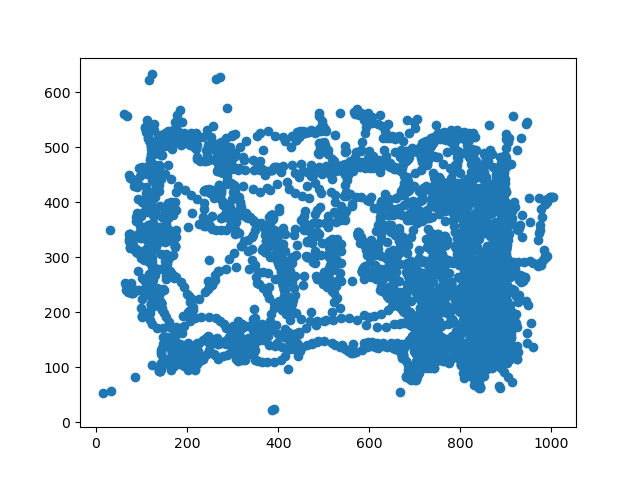

In [154]:
#convert filtered nose data to numpy 2d array
np_intruder_nose = filt_intruder_nose.to_numpy()

np_intruder_nose_x = np.array(np_intruder_nose[:,0],dtype = float)
np_intruder_nose_y = np.array(np_intruder_nose[:,1],dtype = float)

plt.figure(3)
plt.plot(np_intruder_nose_x,np_intruder_nose_y,'o')
plt.show()

(7, 7433, 2)


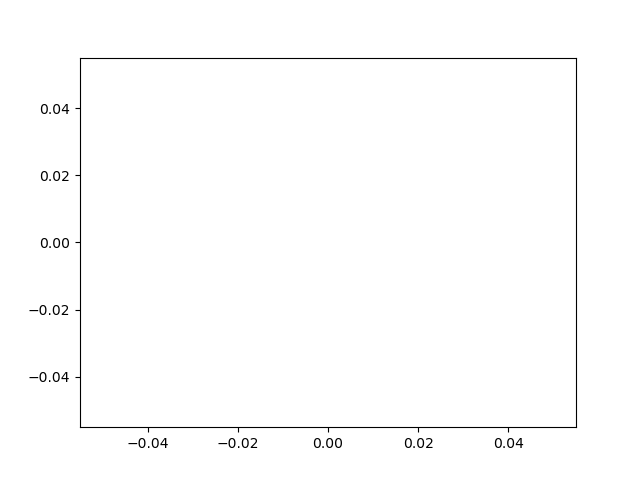

In [51]:
#plotting animation

print(np.shape(copy_intruder_part))

plt.close('all')

fig,ax = plt.subplots()
xdata,ydata = [],[]
ln, = ax.plot([],[],'ro')

def init():
    ax.set_xlim(np.min(copy_intruder_part[0,:,0]),np.max(copy_intruder_part[0,:,0]))
    ax.set_ylim(np.min(copy_intruder_part[0,:,1]),np.max(copy_intruder_part[0,:,1]))
    return ln,

def update(i):
    ln.set_data([copy_intruder_part[0,:,0]],copy_intruder_part[0,:,1])
    return ln,

ani = FuncAnimation(fig,update,frames=len(copy_intruder_part[0,:,0]),init_func=init,blit=True,interval=30,repeat=False)
plt.show()